# Introduction

Fix $n \in \lbrace 2, 3 \rbrace.$ The $\textbf{$n$-dimensional Rubik's Cube}$ is a cube such that each of its $6$ square faces is partitioned into $n^2$ smaller colored squares, known as $\textbf{stickers}.$ Each sticker takes one color from a set of $6$ distinct colors. We refer to a state of the cube with its $n^2$ colored stickers as a $\textbf{(colored) cube configuration}.$ 

Examples of cube configurations are shown below for $n=2,3,$ respectively.
<table><tr>
    
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%201.gif" alt="Drawing" style="width: 200px;"/> <figcaption> An Arbitrary 2D Rubik's Cube Configuration </figcaption> 
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%201.gif" alt="Drawing" style="width: 200px;"/> <figcaption> An Arbitrary 3D Rubik's Cube Configuration </figcaption>  </td>
</tr></table>

We refer to a $\textbf{solved configuration}$ as a configuration such that each square face has $n^2$ stickers of the same color.

Examples of solved cube configurations are shown below for $n=2,3,$ respectively.
<table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%202x2x2%202.gif" alt="Drawing" style="width: 200px;"/> <figcaption> A Solved 2D Rubik's Cube Configuration </figcaption> 
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%202.gif" alt="Drawing" style="width: 200px;"/> <figcaption> A Solved 3D Rubik's Cube Configuration </figcaption> </td>
</tr></table>

For any cube configuration, we can perform a $\textbf{face rotation (scramble)}$ on it. A face rotation is either a $90$ degrees clockwise rotation or counterclockwise rotation of a particular face.

# Problem Statement

Fix a dimension $n \in \lbrace 2,3 \rbrace,$ and let $\mathcal{G}_n$ to be the set of all possible cube configurations for the $n$-dimensional Rubiks Cube. 

Given an arbitrary cube configuration $c \in \mathcal{G}_n,$ the standard challenge is to $\textbf{solve (unscramble)}$ it, which means to find a minimal number of face rotations $m_c$ needed so that we obtain a solved configuration upon performing such rotations in succession. Define $\textbf{God's number}$ for dimension $n$ to be the number $$M_n=\max_{c \in \mathcal{G}_n} m_c.$$ What is the exact value of $M_n$ ? To answer the first question, we will show how we can identify face rotations as certain permutations upon enumerating the cube stickers. We then iteratively construct the set of all possible function compositions of such permutations (which is a subgroup). The number of iterations needed to do this is precisely God's number. We then show that $\mathcal{G}_n$ can be identified with this subgroup of permutations.


Next, begin with a solved configuration of the cube, and consider the reverse process of unscrambling, namely scrambling. Let $t$ be a fixed number of face rotations made (which we refer to as $\textbf{scrambles}$). Given a configuration $c \in \mathcal{G}_n,$ what is the probability of obtaining $c$ in $t$ scrambles ? As $t$ gets larger and larger, is it possible to obtain most, if not all, configurations in $\mathcal{G}_n$ with equal probability ? To answer these questions, we interpret the process of scrambling as a Stochastic process with state space $\mathcal{G}_n.$ This process is a Markov Chain with an associated probability transition matrix. Using this matrix, for each $t \in \mathbb{N},$ we recursively compute the probability of obtaining any configuration in $\mathcal{G}_n$ in exactly $t$ scrambles. Let $\pi_t$ be the corresponding probability distribution in exactly $t$ scrambles. We measure how close $\pi_t$ is to the discrete uniform distribution $\pi_\infty$ of $\mathcal{G}_n.$ 

$\textbf{Note}:$ In order for all code cells to run without errors, please run the code cell below, which imports all the needed libraries. If a certain library fails to import, run the magic command 
<code>!pip3 install \<insert library name here\></code> in a new cell (make sure this is run in a Code cell and not in Markdown).

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/RubiksCubeMarkovChain')
import numpy as np
import scipy as sc
import scipy.sparse
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sympy.combinatorics import SymmetricGroup, Permutation
import json
face_names=['Front','Left','Up','Back','Right','Down']
basic_moves=['F','L','U','B','R','D']
move_dict=dict(zip(basic_moves, face_names))
move_dict

Mounted at /content/drive


{'B': 'Back', 'D': 'Down', 'F': 'Front', 'L': 'Left', 'R': 'Right', 'U': 'Up'}

# Helper Functions

In [2]:
def create_directory(directory):
    try:
        os.makedirs(directory)
    except:
        pass


def delete_unnecessary_moves(seq,n):
    if n==2:
        seq=seq.replace("B",'FFF').replace("R",'LLL').replace("D",'UUU')
    while True:
        try:
            unnecessary_move=next(basic_move for basic_move in basic_moves if 4*basic_move in seq)
            seq=seq.replace(4*unnecessary_move,'')
        except:
            return seq

# Orienting the Cube

Fix a dimension $n \in \lbrace 2,3 \rbrace.$ The diagram below identifies the front (F), left (L), up (U), back (B), right (R), down (D) faces of a cube configuration.

<!-- <table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%20znaceni%20tahu%201.png" alt="Drawing" with="100px"/> <figcaption>Configuration with Identified Faces and their Clockwise Orientations </figcaption> </td>
</tr></table>
 -->

<table><tr>
<td> <img src="https://images.saymedia-content.com/.image/c_limit%2Ccs_srgb%2Cq_auto:eco%2Cw_1200/MTc0MjYyNzAyNzY2NTY1MjQ0/rubik-cube-algorithms.webp" alt="Drawing" width="500px"/> <figcaption>Configuration with Identified Faces and Orientations </figcaption> </td>
</tr></table>

Using the diagram above, we view each face with the orientation such that the face in question appears directly in front of the screen and:
* For F: The corresponding red arrow appears on the top of the face and is facing right on the screen.
* For L: The corresponding red arrow appears on the right of the face and is facing down on the screen.
* For U: The corresponding red arrow appears on the bottom of the face and is facing left on the screen.
* For B: The corresponding red arrow appears on the top of the face and is facing right on the screen.
* For R: The corresponding red arrow appears on the left of the face and is facing up on the screen.
* For D: The corresponding red arrow appears on top of the face and is facing right on the screen.

A face rotation is a $90$ degree clockwise (or counterclockwise) rotation of a face relative to its appropriate orientation as described in the aforementioned bullet points.

# Cube Sticker Enumeration 

Let $\iota$ be a solved configuration. We enumerate all its $6n^2$ stickers from the set $\lbrace 0, \ \dots \ , 6n^2-1 \rbrace$ in the following order of faces: F,L,U,B,R,D, in which we view each face according to the aforementioned orientation procedure. We enumerate the stickers of each given face in row-wise fashion. 

For example, in the case $n=2,$ if identify each face of $\iota$ as a $2 \times 2$ matrix with enumerated stickers as entries, the enumeration procedure above will yield: 
$$F= \begin{bmatrix} 0 & 1 \\ 2 & 3 \end{bmatrix},  \ L= \begin{bmatrix} 4 & 5 \\ 6 & 7 \end{bmatrix},  \ U= \begin{bmatrix} 8 & 9 \\ 10 & 11 \end{bmatrix}, \ B = \begin{bmatrix} 12 & 13 \\ 14 & 15 \end{bmatrix}, \ R = \begin{bmatrix} 16 & 17 \\ 18 & 19 \end{bmatrix}, \ D= \begin{bmatrix} 20 & 21 \\ 22 & 23 \end{bmatrix}.$$

In [4]:
def get_solved_cube_configuration(n):
    face_matrices = [np.arange(j*n**2, (j+1)*n**2).reshape(n,n) for j in range(6)]
    solved_cube_configuration=dict(zip(face_names,face_matrices))
    return solved_cube_configuration

n = 2
solved_cube_configuration = get_solved_cube_configuration(n)
solved_cube_configuration

{'Back': array([[12, 13],
        [14, 15]]), 'Down': array([[20, 21],
        [22, 23]]), 'Front': array([[0, 1],
        [2, 3]]), 'Left': array([[4, 5],
        [6, 7]]), 'Right': array([[16, 17],
        [18, 19]]), 'Up': array([[ 8,  9],
        [10, 11]])}

In [5]:
# iamthecube_configuration={'Front': np.array([1,2,3,4,5,6,7,8,9]).reshape(3,3),
#                           'Left': np.array([18,10,1,21,13,4,24,15,7]).reshape(3,3),
#                           'Up': np.array([18,19,20,10,11,12,1,2,3]).reshape(3,3),
#                           'Back': np.array([20,19,18,23,22,21,26,25,24]).reshape(3,3),
#                           'Right': np.array([3,12,20,6,14,23,9,17,26]).reshape(3,3),
#                           'Down': np.array([7,8,9,15,16,17,24,25,26]).reshape(3,3)} 
# iamthecube_configuration # https://iamthecu.be/.com

# Obtaining New Configurations by Clockwise Rotation

In the code cell below, we implement all the possible the clockwise and counterclockwise face rotation movements applied to any cube configuration with enumerated stickers. 

In [6]:
def rotate_face(configuration,face_name):
    old_front, old_left, old_up, old_back, old_right, old_down = [face_matrix.copy() 
                                                                  for face_matrix in configuration.values()]
    new_front, new_left, new_up, new_back, new_right, new_down = [face_matrix.copy() 
                                                                  for face_matrix in configuration.values()]
    
    if face_name == 'Front':
        new_front = old_front[::-1].T
        new_up[-1] = old_left[:,-1][::-1]
        new_right[:,0] = old_up[-1]
        new_down[0] = old_right[:,0][::-1]
        new_left[:,-1] = old_down[0]
        
    if face_name == 'Left':
        new_left = old_left[::-1].T
        new_up[:,0] = old_back[:,-1][::-1]
        new_front[:,0] = old_up[:,0]
        new_down[:,0] = old_front[:,0]
        new_back[:,-1] = old_down[:,0][::-1]
        
    if face_name == 'Up':
        new_up = old_up[::-1].T
        new_back[0]=old_left[0]
        new_right[0]= old_back[0]
        new_front[0] =old_right[0]
        new_left[0] = old_front[0]
        
    if face_name == 'Back':
        new_back = old_back[::-1].T
        new_up[0] = old_right[:,-1]
        new_left[:,0] = old_up[0][::-1]
        new_down[-1]= old_left[:,0]
        new_right[:,-1]=old_down[-1][::-1]
        
    if face_name == 'Right':
        new_right = new_right[::-1].T
        new_up[:,-1] = old_front[:,-1]
        new_back[:,0] = old_up[:,-1][::-1]
        new_down[:,-1] = old_back[:,0][::-1]
        new_front[:,-1] = old_down[:,-1]
        
    if face_name == 'Down':
        new_down = new_down[::-1].T
        new_front[-1] = old_left[-1]
        new_right[-1] = old_front[-1]
        new_back[-1] = old_right[-1]
        new_left[-1] = old_back[-1]
        
    
    new_configuration=dict(zip(face_names, [new_front, new_left, new_up, new_back, new_right, new_down]))
    return new_configuration


def move(configuration,seq):
    n=len(configuration['Front'])
    seq=delete_unnecessary_moves(seq,n)
    new_configuration = configuration
    for move in seq:
        new_configuration = rotate_face(new_configuration,face_name=move_dict[move])
    return new_configuration
    
def configuration_equal(configuration1,configuration2):
    for key in configuration1.keys():
        if list(configuration1[key].reshape(-1)) != list(configuration2[key].reshape(-1)):
            return False
    return True
    
move(solved_cube_configuration,'D')

{'Back': array([[16, 17],
        [14, 15]]), 'Down': array([[20, 21],
        [22, 23]]), 'Front': array([[4, 5],
        [2, 3]]), 'Left': array([[12, 13],
        [ 6,  7]]), 'Right': array([[ 0,  1],
        [18, 19]]), 'Up': array([[ 9, 11],
        [ 8, 10]])}

# Identifying Cube Configurations with Permutations

Recall $S_m$ is the set of all bijections from the set $\lbrace 0, \ \dots \ , m-1 \rbrace$ to itself. Elements of $S_m$ are known as $\textbf{permutations}.$ Recall that $S_m$ is a group under function composition. 

Recall a permutation $\tau \in S_m$ is a $\textbf{cyclic permutation}$ if there exist distinct $i_1, \ \dots \ , i_k \in \lbrace 0, \ \dots \ , m-1 \rbrace$  such that $\tau(i_j)=\tau_{i_{j+1}}$ for all $1 \le j \le k-1$ and $\tau(i_k)=i_1.$ In this case, we adopt the conventional $\textbf{cyclic notation},$ in which we write $\tau=(i_1 \ \dots \  i_k).$ Let $\tau=(i_1 \ \dots \  i_k)$ and $\kappa=(j_1 \ \dots \  j_m)$ be cyclic permutations in $S_m.$ We say $\tau$ and $\kappa$ are $\textbf{disjoint}$  if the sets $\lbrace i_1, \ \dots \ , i_k \rbrace$ and $\lbrace j_1, \ \dots \ , i_m \rbrace$ are disjoint. It is a well-known theorem from abstract algebra that every $\sigma \in S_m$ can be written as a composition of pairwise disjoint cyclic permutations in $S_m.$


We identify our chosen solved configuration with the identity permutation $\textbf{Id} \in S_{6n^2}.$ A face rotation is formally a permutation of enumerated stickers from $S_{6n^2}.$ We denote $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \in S_{6n^2}$ as the clockwise face rotations corresponding to the faces F,L,U,B,R, and D, respectively. 

In the code cell below, we compute $\mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D}$ for the case $n=2.$ Note the permutations are written in $\textbf{cyclic notation}.$ 

$\textbf{Note}:$ When $n=2,$ for any cube configuration, one can confirm by inspection that rotating the front face thrice yields the same configuration as rotating the back face (up to vantage point). Hence, in the case $n=2,$ we replace $\mathbf{B}$ with $\mathbf{F}^3.$ Similarly, we replace $\mathbf{D}$ with $\mathbf{U}^3$ and $\mathbf{R}$ with $\mathbf{L}^3.$ We cannot do such replacements for $n=3.$

In [7]:
def get_permutation(seq,n):
    solved_configuration = get_solved_cube_configuration(n)
    new_configuration = move(solved_configuration,seq)
    enumerated_stickers = [entry for face_matrix in new_configuration.values() for entry in face_matrix.reshape(-1)]
    permutation = Permutation(enumerated_stickers,size=6*n**2)
    return permutation

def get_basic_permutations(n):
    F,L,U,B,R,D=[get_permutation(basic_move,n) for basic_move in basic_moves]
    if n == 2:
        B,R,D=F*F*F,L*L*L,U*U*U
    return F,L,U,B,R,D


def get_Rubiks_subgroup(n):
    basic_permutations = get_basic_permutations(n)
    Hn=SymmetricGroup(6*n**2).subgroup(basic_permutations)
    return Hn

basic_permutations = get_basic_permutations(n)
# Hn=get_Rubiks_subgroup(n)
basic_permutations

(Permutation(23)(0, 2, 3, 1)(5, 20, 18, 11)(7, 21, 16, 10),
 Permutation(23)(0, 8, 15, 20)(2, 10, 13, 22)(4, 6, 7, 5),
 Permutation(23)(0, 16, 12, 4)(1, 17, 13, 5)(8, 10, 11, 9),
 Permutation(23)(0, 1, 3, 2)(5, 11, 18, 20)(7, 10, 16, 21),
 Permutation(23)(0, 20, 15, 8)(2, 22, 13, 10)(4, 5, 7, 6),
 Permutation(23)(0, 4, 12, 16)(1, 5, 13, 17)(8, 9, 11, 10))

# Iteratively Generating The Subgroup of Permutations

Define the subgroup $H_n= \langle \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rangle$ in $S_{6n^2},$ which is the subgroup generated by the face rotations. We construct $H_n$ iteratively as follows: 

* We first initialize $H_n = \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ 
* For each $\sigma \in H_n,$ we compute the permutation $\mathbf{M} \circ \sigma$ for each $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ If $\mathbf{M} \circ \sigma \notin H_n$ for some $\mathbf{M},$ we update $H_n= H_n \cup \lbrace \mathbf{M} \circ \sigma \rbrace.$ Otherwise, no update is needed.
* We repeat the previous step until $\mathbf{M} \circ \sigma \in H_n$ for all $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace$ and all $\sigma \in H_n.$

The minimum number of iterations needed to produce $H_n$ is precisely God's Number. Experimentation for the case $n=2$ showed God's Number to be $14.$ It was proven by Google that the case $n=3$ would require $20$ iterations, but we do not have computing power to rearrive at this result. 

We implement this iterative algorithm in the code cell below. We also load $H_2$ in the code cell below.

In [8]:
def load_current_permutations(n, update=False):
    directory='{}D'.format(n)
    create_directory(directory)
    file_path="{}/All_Permutations.json".format(directory)
    
    current_permutations_dict=None
    
    if os.path.exists(file_path):
        with open(file_path,'r') as f:
            print("Loading Existing Permutation Lists ...")
            current_permutations_dict = json.load(f)
            keys=[int(x) for x in current_permutations_dict.keys()]
            current_permutations_dict=dict(zip(keys,
                                               current_permutations_dict.values()))
            print("DONE !!!")
    else:
        update=True
        current_permutations_dict ={0 : list(range(6*n**2))}
    
    if update:
        basic_permutations= get_basic_permutations(n)
        
        print("Converting Existing Permutation Lists ...")
        current_permutations={Permutation(val,size=6*n**2) for val in current_permutations_dict.values()}
        print("DONE !!!")
        
        print("Obtaining All Attainable Permutations ... ")
        attainable_permutations={basic_permutation * permutation for basic_permutation in basic_permutations
                          for permutation in current_permutations}
        print("DONE !!!")
        
        print("Deleting Redundant Permutations ...")
        new_permutations = attainable_permutations - current_permutations
        print("DONE !!!")
        if len(new_permutations) !=0:
            keys=range(len(current_permutations), len(current_permutations) + len(new_permutations))
            vals=[list(new_permutation) for new_permutation in new_permutations]

            print("Updating Permutations Dictionary ...")
            current_permutations_dict.update(dict(zip(keys,vals)))
            print("DONE !!!")
        
            with open(file_path ,'w') as f:
                print("SAVING Permutations Dictionary ...")
                json.dump(current_permutations_dict,f)
                print("DONE !!!")
    return current_permutations_dict
    
# H2 = load_current_permutations(n)

# Formally Interpretting Cube Scrambling as a Markov Chain

Identify $\mathcal{G}_n$ with $H_n$ from above. Enumerate $\mathcal{G}_n=\lbrace g_1, \ \dots \ , g_N \rbrace,$ where each $g_i$ is a composition of different face rotation permutations (such individual permutations are either clockwise or counterclockwise permutations) and $N=|\mathcal{G}_n|.$

For each $t \in \mathbb{N},$ define the random variable $G_t,$ which is the permutation obtained after composing $t$ face rotation permutations to a solved configuration. Each $G_t$ has sample space $\mathcal{G}_n.$ We call the sequence of random variables $\lbrace G_t \rbrace_{t \in \mathbb{N}}$ the $\textbf{scrambling chain}.$ 

Note that $\lbrace G_t \rbrace_{t \in \mathbb{N}}$ is a Markov Chain. Indeed, for any $t \in \mathbb{N}$ and any $g_1, \ \dots \ , g_{t+1} \in \mathcal{G}_n,$ we see that the conditional probability
\begin{align*}
\Pr(G_{t+1} = g_{t+1} \ | \ G_t=g_t, \ \dots\ , G_1=g_1) &= \begin{cases} 1/6 & g_{t+1} = \mathbf{M} \circ g_t  \text{ for some $\mathbf{M} \in \lbrace \mathbf{F}, \mathbf{L}, \mathbf{U}, \mathbf{B}, \mathbf{R}, \mathbf{D} \rbrace$} \\
0 & \text{else}.
\end{cases}
\end{align*}
Clearly, this is the same as the conditional probability $\Pr(G_{t+1} = g_{t+1} \ | \ G_t=g_t).$ 

Associated with this Markov Chain is an $N \times N$ probability transition matrix $P,$ where the $(i,j)$-th entry of $P$ is the conditional probability $$P_{i,j}=\Pr(G_{i}=g_i | G_j=g_j).$$ Note $P$ is a symmetric matrix i.e. $P$ is equal to its transpose. Furthermore $P$ is a sparse matrix; each row has exactly $6$ nonzero entries, all of which are equal to $1/6$.   

In the code cell below, we obtain a sparse matrix representation for the probability transition matrix in the case $n=2.$

In [9]:
def load_transition_matrix_nonzero_entry_row_column_indices_dict(n,stopping_index=None,update=False):
    directory='{}D'.format(n)
    create_directory(directory)
    file_path="{}/Transition_Matrix_Nonzero_Entry_Row_Column_Indices.json".format(directory)
    
    transition_matrix_nonzero_entry_row_column_indices_dict = dict()
    if os.path.exists(file_path):
        with open(file_path,'r') as f:
            print("Loading Transition Matrix Nonzero Entry Indices Dictionary ...")
            transition_matrix_nonzero_entry_row_column_indices_dict = json.load(f)
            keys=[int(x) for x in transition_matrix_nonzero_entry_row_column_indices_dict.keys()]
            transition_matrix_nonzero_entry_row_column_indices_dict = dict(zip(keys,
                                               transition_matrix_nonzero_entry_row_column_indices_dict.values()))
            print("DONE !!!")
    else:
        update=True
    
    if update:

        basic_permutations = get_basic_permutations(n)
        current_permutations_dict = load_current_permutations(n,False)
        print("Converting Permutations Lists ...")
        values=[Permutation(val,size=6*n**2) for val in current_permutations_dict.values()]
        print("DONE !!!")
        
        current_permutations_dict=dict(zip(current_permutations_dict.keys(),values))
        reversed_dict=dict(zip(current_permutations_dict.values(), current_permutations_dict.keys()))
        N=len(current_permutations_dict)
        if stopping_index == None:
            stopping_index=N
        
        try:
            incomplete_index = next(row_index for row_index in range(N) if row_index not in transition_matrix_nonzero_entry_row_column_indices_dict.keys()
                                   or len(transition_matrix_nonzero_entry_row_column_indices_dict[row_index]) != 6)
            
            for row_index in range(incomplete_index, stopping_index):
                
                if row_index not in transition_matrix_nonzero_entry_row_column_indices_dict.keys() \
                or len(transition_matrix_nonzero_entry_row_column_indices_dict[row_index]) != 6:
        
                    current_permutation = current_permutations_dict[row_index]
                    attainable_permutations = {basic_permutation*current_permutation
                                               for basic_permutation in basic_permutations}
                    nonzero_column_indices=sorted([reversed_dict[permutation] for permutation in attainable_permutations
                                                  if permutation in reversed_dict.keys()])
                    transition_matrix_nonzero_entry_row_column_indices_dict.update({row_index : nonzero_column_indices })
            
            with open(file_path ,'w') as f:
                print("SAVING Transition Matrix Nonzero Entry Row Column Indices Dictionary ...")
                json.dump(transition_matrix_nonzero_entry_row_column_indices_dict,f)
                print("DONE !!!")
            return transition_matrix_nonzero_entry_row_column_indices_dict
            
        except:
            return transition_matrix_nonzero_entry_row_column_indices_dict
        
    return transition_matrix_nonzero_entry_row_column_indices_dict


def get_transition_matrix_coo_format(n,update=False):
    directory='{}D'.format(n)
    create_directory(directory)
    file_path="{}/Transition_Matrix.npz".format(directory)
    
    transition_matrix= None
    if os.path.exists(file_path):
        transition_matrix = sc.sparse.load_npz(file_path)
    else:
        update=True
    if update:
        transition_matrix_nonzero_entry_row_column_indices_dict = \
        load_transition_matrix_nonzero_entry_row_column_indices_dict(n)

        ij_tuples=[(row_index,col_index) for row_index in transition_matrix_nonzero_entry_row_column_indices_dict.keys() 
                     for col_index in transition_matrix_nonzero_entry_row_column_indices_dict[row_index]]

        rows = np.array([t[0] for t in ij_tuples])
        cols = np.array([t[-1] for t in ij_tuples])
        data = np.repeat(1/6,len(rows))
        N=len(transition_matrix_nonzero_entry_row_column_indices_dict)
        transition_matrix=sc.sparse.coo_matrix((data,(rows,cols)),shape=(N,N))
        print("Saving Sparse Transition Matrix ...")
        sc.sparse.save_npz(file_path,transition_matrix)
        print("DONE !!!")
    return transition_matrix
    

transition_matrix=get_transition_matrix_coo_format(n)
transition_matrix

<3674160x3674160 sparse matrix of type '<class 'numpy.float64'>'
	with 22044960 stored elements in COOrdinate format>

# Obtaining Markov Chain Distributions

For each $t \in \mathbb{N},$ we define $\pi_t$ to be the probability distribution corresponding to the random variable $G_t.$ By Bayes Rule, for each $i \in \lbrace 1, \ \dots \ , N \rbrace,$ we have
\begin{align*}
    \pi_{t+1}(g_i) &= \sum_{j=1}^N P_{i,j} \pi_{t}(g_j).
\end{align*}
Writing $\boldsymbol{\pi}_t=(\pi_t(g_1), \ \dots \ , \pi_t(g_N)) \in \mathbb{R}^N,$ the above equation is equivalent to the matrix equality 
$$\boldsymbol{\pi}_{t+1} = P \boldsymbol{\pi}_t.$$

We implement this formula in the code cell below via sparse matrix multiplication.

In [10]:
def get_chain_distribution(n,t):
    directory='{}D/Chain_Distributions'.format(n)
    create_directory(directory)
    file_path="{}/Chain_Distribution_{}.npz".format(directory,t)
    transition_matrix=get_transition_matrix_coo_format(n)
    
    chain_distribution=None
    if os.path.exists(file_path):
        chain_distribution=sc.sparse.load_npz(file_path)
    
    else:
        if t == 0:
            N=transition_matrix.shape[0]
            I=sc.sparse.identity(N)
            chain_distribution = I.getcol(0)
        else:
            chain_distribution = transition_matrix * get_chain_distribution(n,t-1)
            
        if np.isclose(chain_distribution.data.sum(), 1.0):
            print("Saving Chain Distribution ...")
            sc.sparse.save_npz(file_path,chain_distribution)
            print("DONE !!!")
    return chain_distribution

pi1=get_chain_distribution(n,1)
pi1.data

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

We plot $\boldsymbol{\pi}_t$ for some small values of $t.$ In each plot, the horizontal axis is the permutation index (according to our enumeration scheme), and the vertical axis is $\pi_t(g_i)$ where $g_i \in \mathcal{G}_n$ is the $i$-th permutation in $\mathcal{G}_n$ (according to our enumeration scheme). 

For even values of $t,$ we conjecture that $\pi_t(\mathbf{Id}_{6n^2}) > \pi_t(g)$ for each $g \in \mathcal{G}_n \setminus \lbrace \mathbf{Id}_{6n^2} \rbrace.$ In words, we conjecture it is more likely to return back to the solved configuration after an even number of scrambles. Hence, it may not be theoretically possible to scramble the cube. 

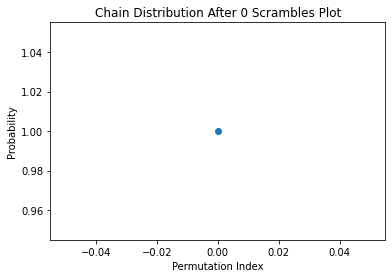

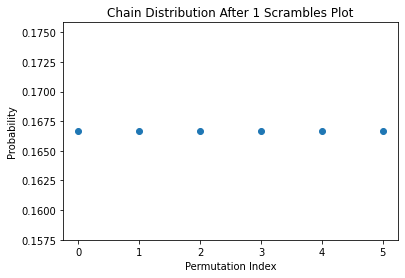

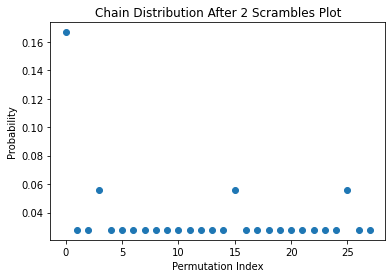

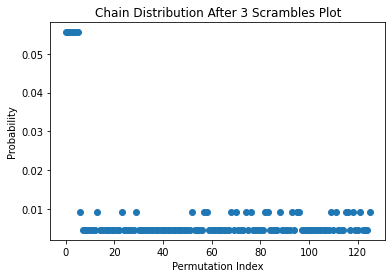

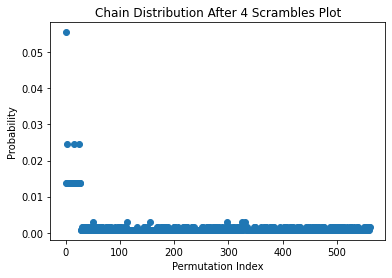

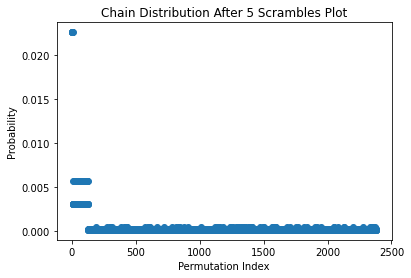

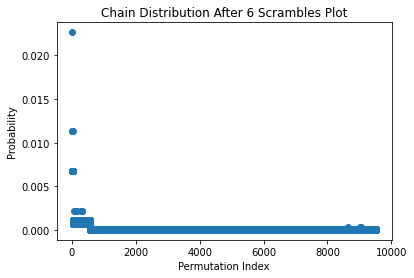

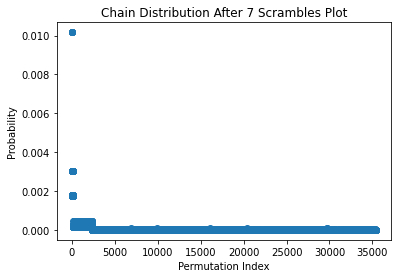

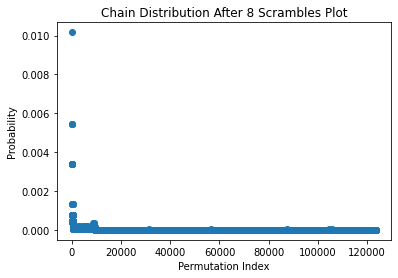

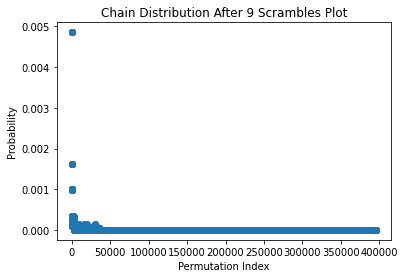

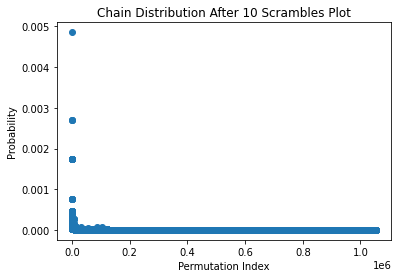

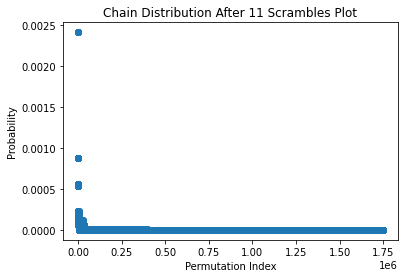

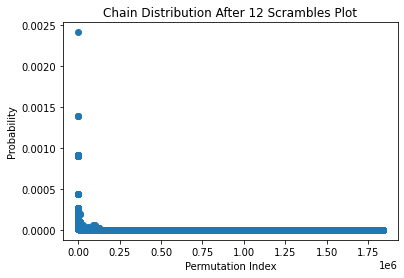

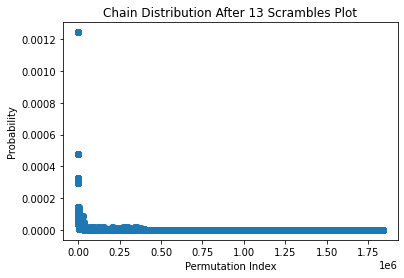

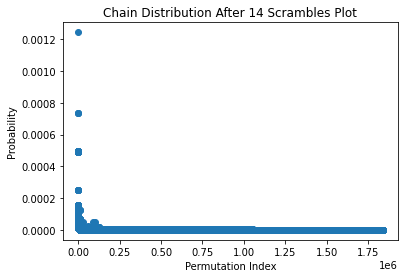

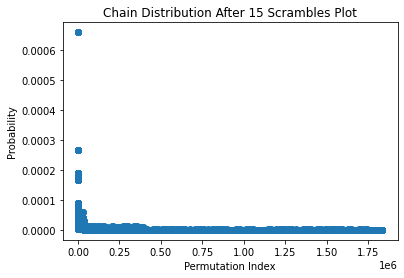

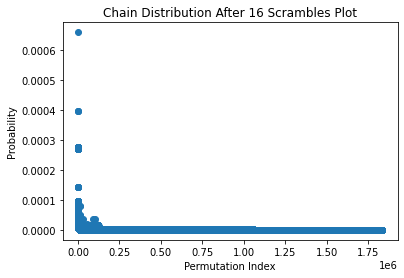

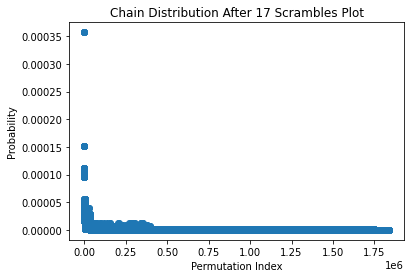

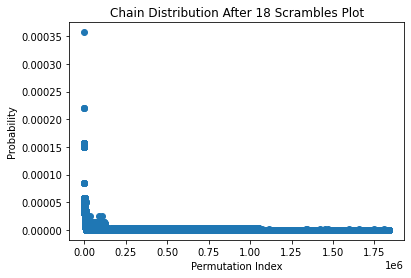

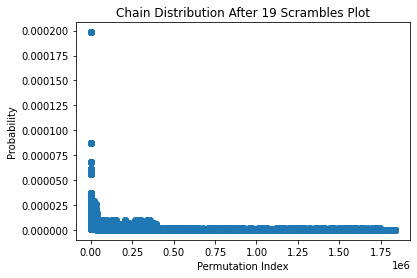

In [11]:
t=20
pis=Parallel(n_jobs=t, 
             prefer='threads')(delayed(get_chain_distribution)(n,j) for j in range(t))

for j in range(t):
    pi=pis[j].data
    fig,ax=plt.subplots()
    ax.scatter(range(len(pi)), pi)
    ax.set_title('Chain Distribution After {} Scrambles Plot'.format(j))
    ax.set_xlabel('Permutation Index')
    ax.set_ylabel('Probability')

# Total Variation Distance To Uniform
Consider the discrete uniform distribution $\pi_\infty$ on $\mathcal{G}_n,$ that is, $\pi_\infty(g)=1/N$ for each $g \in \mathcal{G}_n,$ where $N=|\mathcal{G}_n|$ as before. For each $t \in \mathbb{N},$ we compute the $\textbf{total variation distance}$ of $\pi_t$ to $\pi_\infty,$ which is the quantity
$$\text{TV}(\pi_t,\pi_\infty) = \frac{1}{2} \|\boldsymbol{\pi}_t - \boldsymbol{\pi}_\infty \|_1,$$ where $\boldsymbol{\pi}_\infty=(1/N, \ \dots \ , 1/N) \in \mathbb{R}^N$ and $\| \cdot \|_1$ is the Euclidean $1$-norm.

We show a plot of the total variation distances for $t \le 29.$ There is all the more evidence pointing towards it being theoretically impossible to scramble the cube. We conjecture based on simulation that $$\lim_{t \in \mathbb{N}}\text{TV}(\pi_t,\pi_\infty) = 1/2.$$ 

Text(0.5, 1.0, 'Markov Chain Total Variation Distances to Uniform After Scrambling')

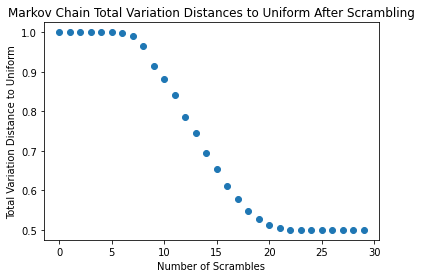

In [12]:
def compute_total_variation_distance_to_uniform(n,t):
    chain_dist=get_chain_distribution(n,t)
    N=chain_dist.shape[0]
    data=chain_dist.data
    total_variation_distance_to_uniform = 0.5*np.linalg.norm(data-1/N,1) + 0.5 *(N-len(data))/N
    return total_variation_distance_to_uniform

t=30
tv_dists = Parallel(n_jobs=t, 
             prefer='threads')(delayed(compute_total_variation_distance_to_uniform)(n,j) 
                          for j in range(t))
fig,ax=plt.subplots()
ax.scatter(range(t),tv_dists)
ax.set_xlabel('Number of Scrambles')
ax.set_ylabel('Total Variation Distance to Uniform')
ax.set_title('Markov Chain Total Variation Distances to Uniform After Scrambling')